In [2]:
import pandas as pd

# Phase 1

In [ ]:
def map_actual(percent):
    if percent <= 20: return 1
    elif 20 < percent <= 40: return 2
    elif 40 < percent <= 60: return 3
    elif 60 < percent <= 80: return 4
    else: return 5

path = "Datasets/Phase1/dataset_phase1.csv"
df_pahse1 = pd.read_csv(path)
cols_to_keep = ["id","specification", "Task" , "num_hidden_test_passed_phase1", "num_hidden_test_failed_phase1", "before_p_8"]
df_pahse1 = df_pahse1[cols_to_keep]
df_pahse1 = df_pahse1.dropna(subset=["before_p_8"])

mapping = {
    # numeric strings
    "1.0": 1,
    "2.0": 2,
    "3.0": 3,
    "4.0": 4,
    "5.0": 5,

    # text labels
    "Not confident at all": 1,
    "Not confident at all (0-20%)": 1,

    "Slightly confident (21-40%)": 2,

    "Moderately confident": 3,
    "Moderately confident (41-60%)": 3,

    "Very confident": 4,
    "Very confident (61-80%)": 4,
    "Very confident (61- 80%)": 4,

    "Extremely confident (81-100%)": 5
}

df_pahse1["before_p_8"] = (
    df_pahse1["before_p_8"]
    .astype(str)
    .str.strip()
    .map(mapping)
)

df_pahse1["Actual_percent"] = df_pahse1["num_hidden_test_passed_phase1"] /(df_pahse1["num_hidden_test_passed_phase1"] +df_pahse1["num_hidden_test_failed_phase1"] ) *100
df_pahse1["actual_categ"] = df_pahse1["Actual_percent"].apply(map_actual)
df_pahse1 = df_pahse1.rename(columns={"before_p_8": "predicted_categ"})

df_pahse1["overconfidence"] = df_pahse1["predicted_categ"] - df_pahse1["actual_categ"]
df_pahse1["overconfidence_pos"] = df_pahse1["overconfidence"].clip(lower=0)
df_pahse1["overconfidence_pct"] = df_pahse1["overconfidence_pos"] / 4 * 100
df_pahse1.to_csv("Datasets/RQ4_phase1.csv", index = False)
table = df_pahse1.groupby("specification")["overconfidence_pct"].mean().reset_index()

table

,specification,overconfidence_pct
0,G1,34.375000
1,G2,12.500000
2,G3,5.208333


# Phase 2

In [ ]:
def map_actual(percent):
    if percent <= 20: return 1
    elif 20 < percent <= 40: return 2
    elif 40 < percent <= 60: return 3
    elif 60 < percent <= 80: return 4
    else: return 5

path = "Datasets/Phase2/dataset_pahse2.csv"
df_pahse2 = pd.read_csv(path)

df_pahse2['specification'] = df_pahse2['version'].str[:2]
# Extract Task (last character)
df_pahse2['Task'] = df_pahse2['version'].str[-1]

cols_to_keep = ["id","specification", "Task" , "num_hidden_test_passed_phase2", "num_hidden_test_failed_phase2", "after_cr_6"]
df_pahse2 = df_pahse2[cols_to_keep]
df_pahse2 = df_pahse2.dropna(subset=["after_cr_6"])
# df_pahse2.head()
# unique_vals = set(df_pahse2["after_cr_6"])
# unique_vals

mapping = {

    'Extremely confident (81-100%)': 5,
    'Moderately confident (41-60%)': 3,
    'Not confident at all (0-20%)': 1,
    'Slightly confident (21-40%)': 2,
    'Very confident (61- 80%)': 4,
    'Very confident (61-80%)': 4
}

df_pahse2["after_cr_6"] = (
    df_pahse2["after_cr_6"]
    .astype(str)
    .str.strip()
    .map(mapping)
)

# unique_vals = set(df_pahse2["after_cr_6"])
# unique_vals

df_pahse2["Actual_percent"] = df_pahse2["num_hidden_test_passed_phase2"] /(df_pahse2["num_hidden_test_passed_phase2"] +df_pahse2["num_hidden_test_failed_phase2"] ) *100
df_pahse2["actual_categ"] = df_pahse2["Actual_percent"].apply(map_actual)
df_pahse2 = df_pahse2.rename(columns={"after_cr_6": "predicted_categ"})

df_pahse2["overconfidence"] = df_pahse2["predicted_categ"] - df_pahse2["actual_categ"]
df_pahse2["overconfidence_pos"] = df_pahse2["overconfidence"].clip(lower=0)
df_pahse2["overconfidence_pct"] = df_pahse2["overconfidence_pos"] / 4 * 100
df_pahse2.to_csv("Datasets/RQ4_phase2.csv", index = False)

table = df_pahse2.groupby("specification")["overconfidence_pct"].mean().reset_index()

table

,specification,overconfidence_pct
0,G1,34.375000
1,G2,9.782609
2,G3,4.347826


# Visualization

In [15]:
import pandas as pd

df = pd.read_csv("Datasets/RQ4_phase1.csv")
cols_to_keep = ["specification", "Task", "predicted_categ", "actual_categ", "overconfidence_pct"]
df = df[cols_to_keep]
df.rename(columns={'predicted_categ': 'predicted_phase1', 'actual_categ': 'actual_phase1', 'overconfidence_pct': 'overconfidence_phase1'}, inplace=True)
table = df.groupby("specification")[df.select_dtypes(include='number').columns].mean().reset_index()
table

,specification,predicted_phase1,actual_phase1,overconfidence_phase1
0,G1,3.375000,2.125000,34.375000
1,G2,2.772727,2.545455,12.500000
2,G3,2.666667,3.708333,5.208333


In [16]:
import pandas as pd

df = pd.read_csv("Datasets/RQ4_phase2.csv")
cols_to_keep = ["specification", "Task", "predicted_categ", "actual_categ", "overconfidence_pct"]
df = df[cols_to_keep]
df.rename(columns={'predicted_categ': 'predicted_phase2', 'actual_categ': 'actual_phase2', 'overconfidence_pct': 'overconfidence_phase2'}, inplace=True)
table = df.groupby("specification")[df.select_dtypes(include='number').columns].mean().reset_index()
table

,specification,predicted_phase2,actual_phase2,overconfidence_phase2
0,G1,3.625000,2.333333,34.375000
1,G2,3.304348,3.956522,9.782609
2,G3,3.304348,4.130435,4.347826


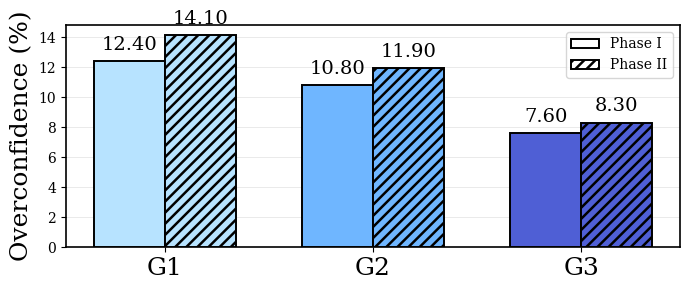

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
# from google.colab import files

# -------------------------------------------------
# Example input
# Replace these with your actual values if needed
# -------------------------------------------------
groups = ["G1", "G2", "G3"]
phase1_vals = [12.4, 10.8, 7.6] # calcualted spearately
phase2_vals = [14.1, 11.9, 8.3]# calcualted spearately

# -------------------------------------------------
# Style
# -------------------------------------------------
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 10,
    "axes.labelsize": 11,
    "axes.facecolor": "white",
    "figure.facecolor": "white",
    "savefig.facecolor": "white"
})

# -------------------------------------------------
# Colors
# -------------------------------------------------
colors = ["#b7e3ff", "#6fb6ff", "#4f5fd5"]

group_colors = {
    "G1": colors[0],
    "G2": colors[1],
    "G3": colors[2],
}

# Stronger hatch visibility
plt.rcParams["hatch.linewidth"] = 1.8

# -------------------------------------------------
# Plot setup
# -------------------------------------------------
x = np.arange(len(groups))
width = 0.34

fig, ax = plt.subplots(figsize=(7, 3))

# Force white background everywhere
fig.patch.set_facecolor("white")
fig.patch.set_alpha(1)
ax.set_facecolor("white")
ax.patch.set_alpha(1)

# -------------------------------------------------
# Bars
# -------------------------------------------------
for i, g in enumerate(groups):
    # Phase I solid
    ax.bar(
        x[i] - width/2,
        phase1_vals[i],
        width=width,
        color=group_colors[g],
        edgecolor="black",
        linewidth=1.4,
        zorder=3
    )

    # Phase II hatched
    ax.bar(
        x[i] + width/2,
        phase2_vals[i],
        width=width,
        color=group_colors[g],
        edgecolor="black",
        linewidth=1.4,
        hatch="///",
        zorder=3
    )

# -------------------------------------------------
# Axes styling
# -------------------------------------------------
ax.set_xticks(x)
ax.set_xticklabels(groups)
# ax.set_xlabel("",)
ax.set_ylabel("Overconfidence (%)", fontsize=18)
ax.tick_params(axis='x', labelsize=18)
ax.grid(axis="y", linestyle="-", linewidth=0.6, alpha=0.3, zorder=0)

for spine in ax.spines.values():
    spine.set_color("black")
    spine.set_linewidth(1.2)

# -------------------------------------------------
# Legend
# -------------------------------------------------
legend_elements = [
    Patch(facecolor="white", edgecolor="black", linewidth=1.4, label="Phase I"),
    Patch(facecolor="white", edgecolor="black", linewidth=1.4, hatch="///", label="Phase II"),
]

ax.legend(handles=legend_elements, loc="upper right", frameon=True)

# -------------------------------------------------
# Value labels
# -------------------------------------------------
for i in range(len(groups)):
    ax.text(
        x[i] - width/2,
        phase1_vals[i] + 0.5,
        f"{phase1_vals[i]:.2f}",
        ha="center",
        va="bottom",
        fontsize=14
    )
    ax.text(
        x[i] + width/2,
        phase2_vals[i] + 0.5,
        f"{phase2_vals[i]:.2f}",
        ha="center",
        va="bottom",
        fontsize=14
    )

plt.tight_layout()

# -------------------------------------------------
# Save PDF with white background and download
# -------------------------------------------------
pdf_name = "overconfidence_plot.pdf"

fig.savefig(
    pdf_name,
    format="pdf",
    bbox_inches="tight",
    facecolor="white",
    edgecolor="white"
)

plt.show()
# files.download(pdf_name)